In [1]:
!pip install -r requirements.txt --quiet


[notice] A new release of pip is available: 25.1.1 -> 26.0
[notice] To update, run: pip install --upgrade pip


In [2]:
%matplotlib inline
import pymc as pm
import numpy as np
import pandas as pd
from scipy.stats import norm, binom, bernoulli, lognorm, betabinom
from scipy.stats import beta as beta_dist
from scipy.special import expit as inv_logit
from scipy.special import logit ,logsumexp
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import arviz as az
import networkx as nx
import xarray as xr

import collections.abc
collections.Iterable = collections.abc.Iterable
from causalgraphicalmodels import CausalGraphicalModel
from sklearn.preprocessing import StandardScaler
scale = StandardScaler()
from matplotlib.patches import FancyArrowPatch

import warnings
warnings.filterwarnings('ignore')


%config InlineBackend.figure_format = 'retina'

plt.style.use(['seaborn-v0_8-darkgrid','seaborn-v0_8-colorblind'])

#### Code 13.1

In [3]:
d = pd.read_csv('data/reedfrogs.csv', sep = ',')
d.describe().T
d.head()

,density,pred,size,surv,propsurv
0,10,no,big,9,0.9
1,10,no,big,10,1.0
2,10,no,big,7,0.7
3,10,no,big,10,1.0
4,10,no,small,9,0.9


#### Code 13.2

In [5]:
d['tank'] = d.index 

#Im going to start loading the data into model itself so its easier to change later.
dat = pd.DataFrame({
    'S': d.surv,
    'N': d.density,
    'tank': d.tank
})

with pm.Model() as m13_1:
    a = pm.Normal('a', 0, 1.5, shape = len(d.tank.unique()))
    p = pm.Deterministic('p', pm.math.sigmoid(a[d.tank]))
    S = pm.Binomial('S', dat.N, p, observed = dat.S)
    trace_m13_1 = pm.sample(1000, tune = 1000, cores = 1, idata_kwargs={'log_likelihood':True})





Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [a]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 2 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


#### Code 13.3

In [6]:
with pm.Model() as m13_2:
    a_bar = pm.Normal('a_bar', 0, 1.5)
    sigma = pm.Exponential('sigma', 1)
    a = pm.Normal('a', a_bar, sigma, shape = len(d.tank.unique()))
    p = pm.Deterministic('p', pm.math.sigmoid(a[d.tank]))
    S = pm.Binomial('S', dat.N, p, observed = dat.S)
    trace_m13_2 = pm.sample(1000, tune = 1000, cores = 1, idata_kwargs={'log_likelihood':True})



Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [a_bar, sigma, a]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 3 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


In [7]:
pm.compare({'m13_1':trace_m13_1, 'm13_2': trace_m13_2}, ic='loo')

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
m13_2,0,-109.317983,30.162479,0.000000,1.000000e+00,3.968649,0.00000,True,log
m13_1,1,-117.614052,35.895784,8.296069,1.723066e-13,2.496953,2.38882,True,log


#### Code 13.4

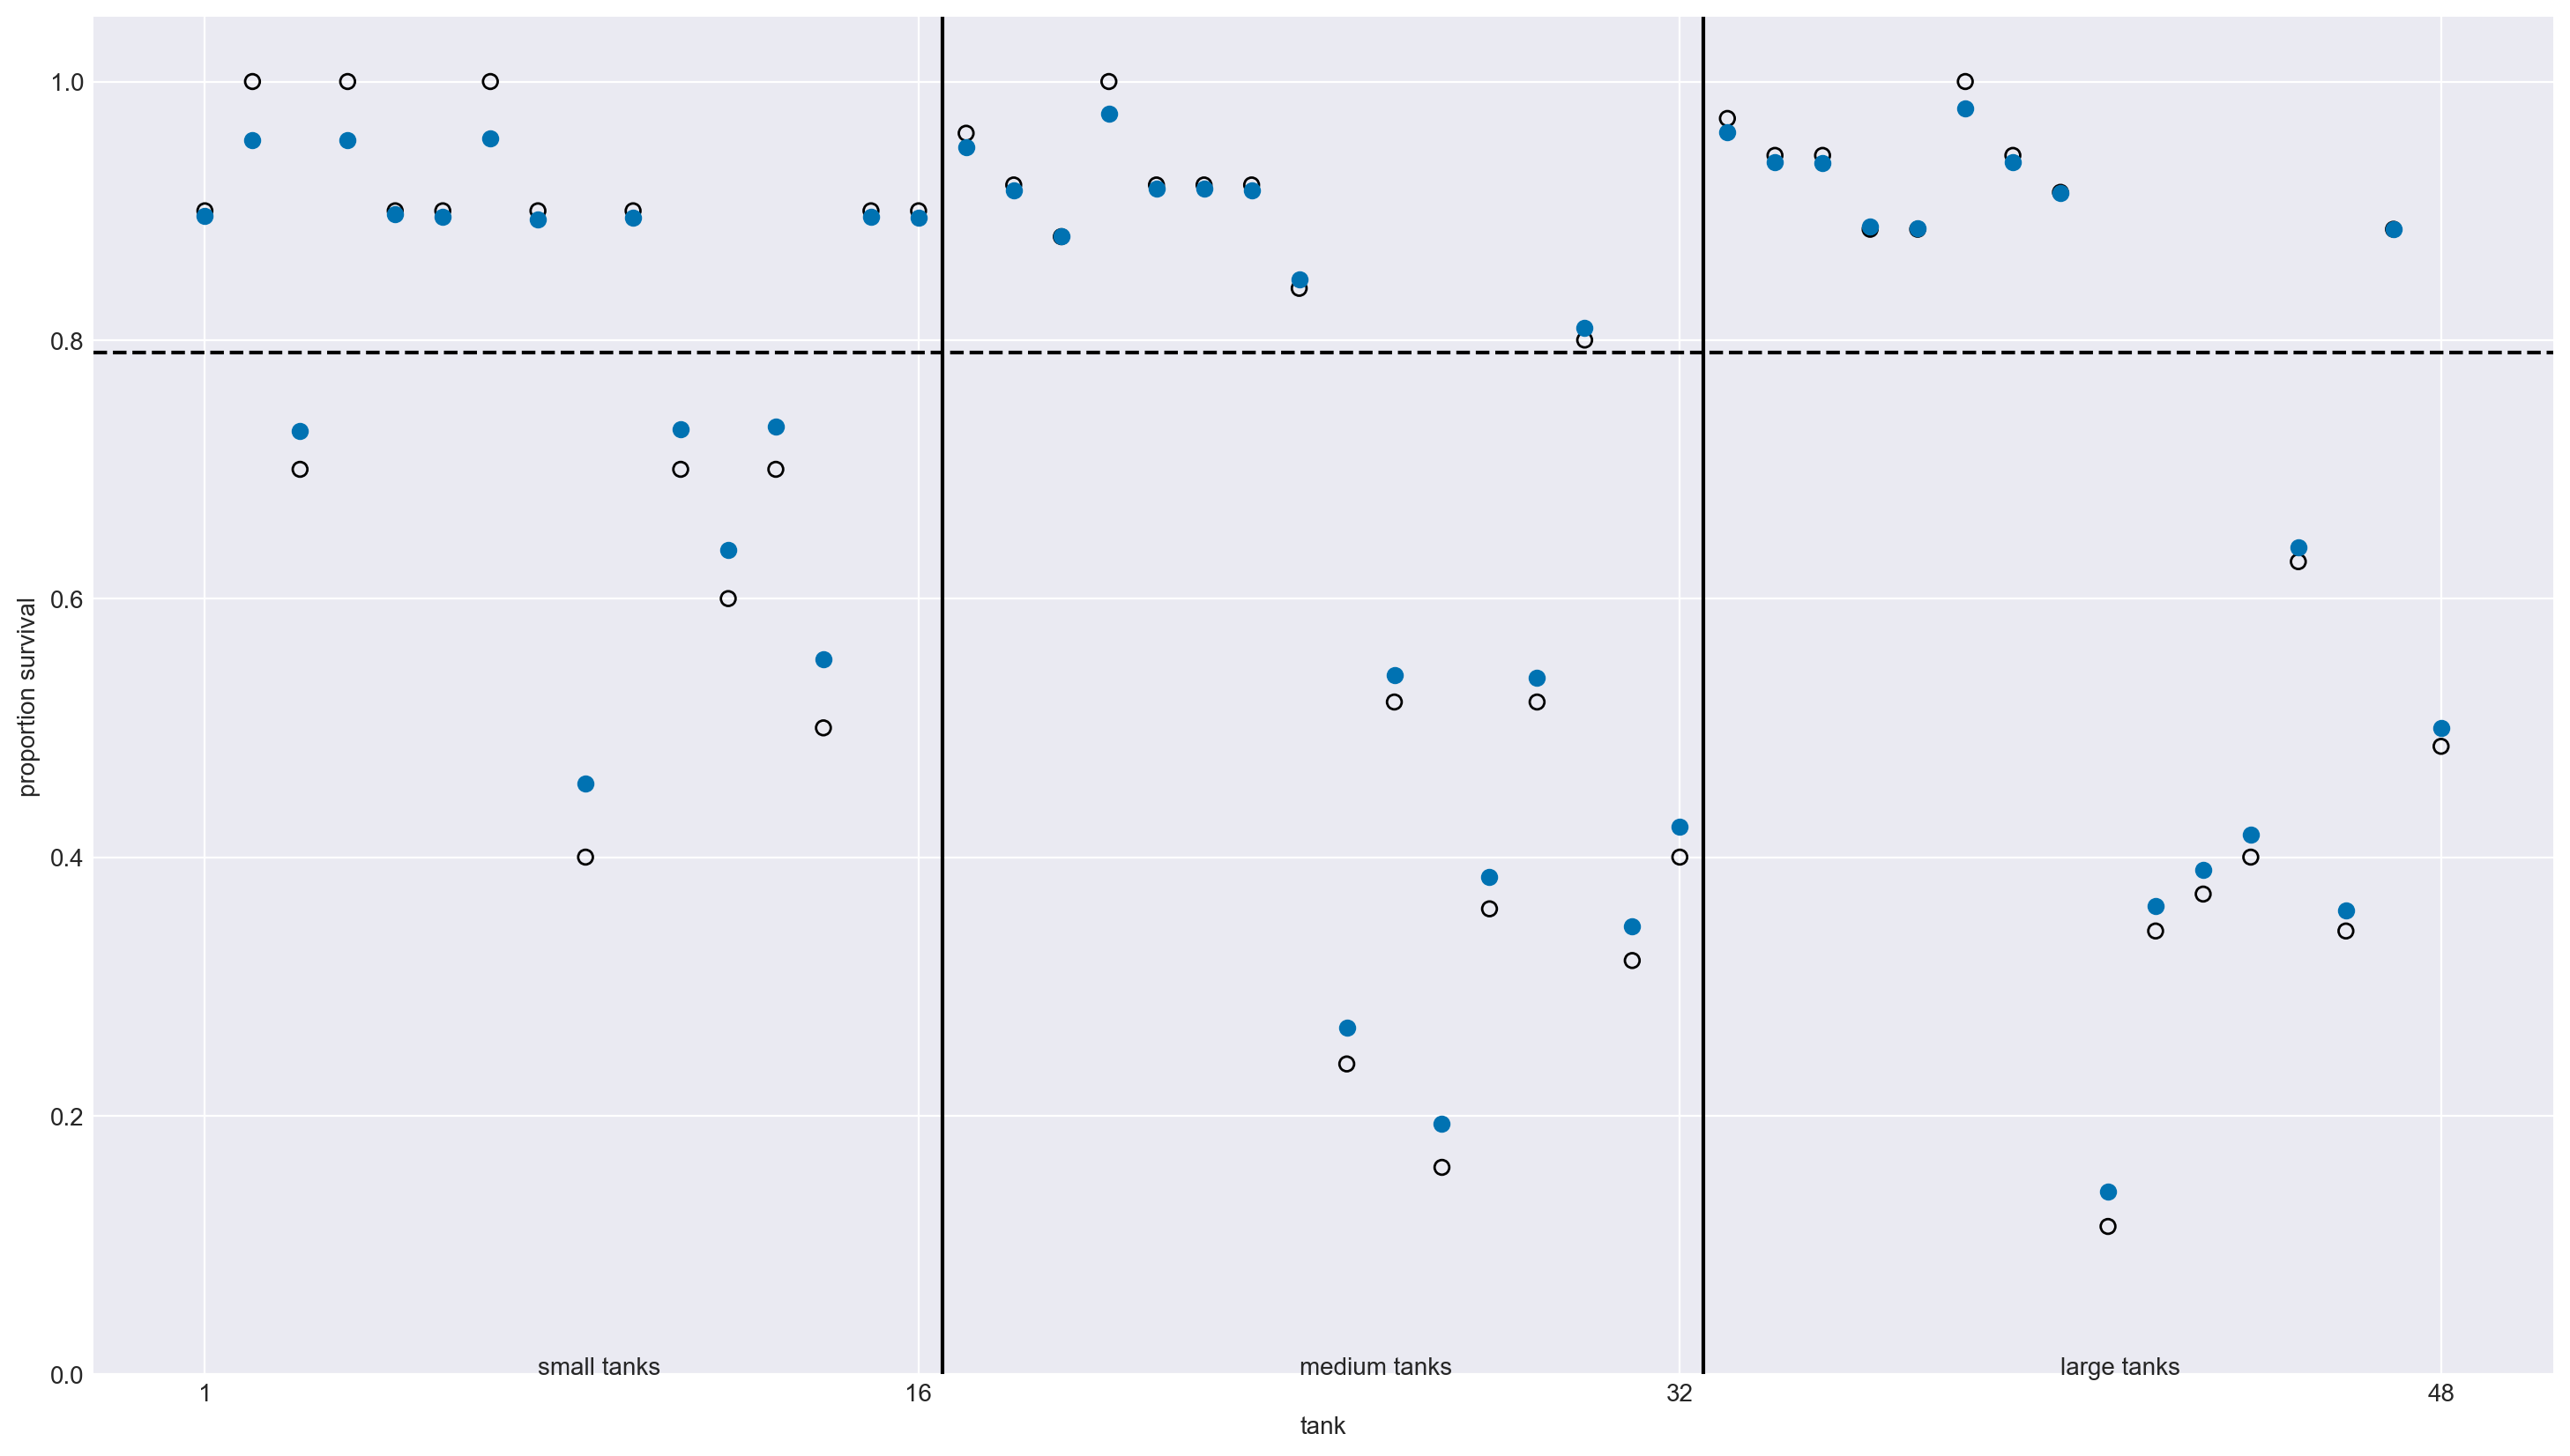

In [8]:
post = trace_m13_2.posterior.to_dataframe().reset_index()

d['propsurv.est'] = inv_logit(post.groupby('a_dim_0').mean())['a']

plt.figure(figsize = (18,10))
plt.ylim(0,1.05)
plt.xlabel('tank')
plt.xticks([1,16,32,48])
plt.ylabel('proportion survival')
plt.axhline(y= np.mean(inv_logit(post.a_bar)), xmin = 0, xmax = 49, linestyle = '--', color='black')
plt.axvline(x = 16.5, ymin = 0, ymax = 1.05, linestyle = '-', color='black')
plt.axvline(x = 32.5, ymin = 0, ymax = 1.05, linestyle = '-', color='black')

plt.scatter(np.arange(1,49), d.propsurv, edgecolor = 'black', facecolor='none');
plt.scatter(np.arange(1,49), d['propsurv.est'])
plt.text(8,0,'small tanks')
plt.text(16+8,0,'medium tanks')
plt.text(32+8,0,'large tanks');


#### Code 13.6

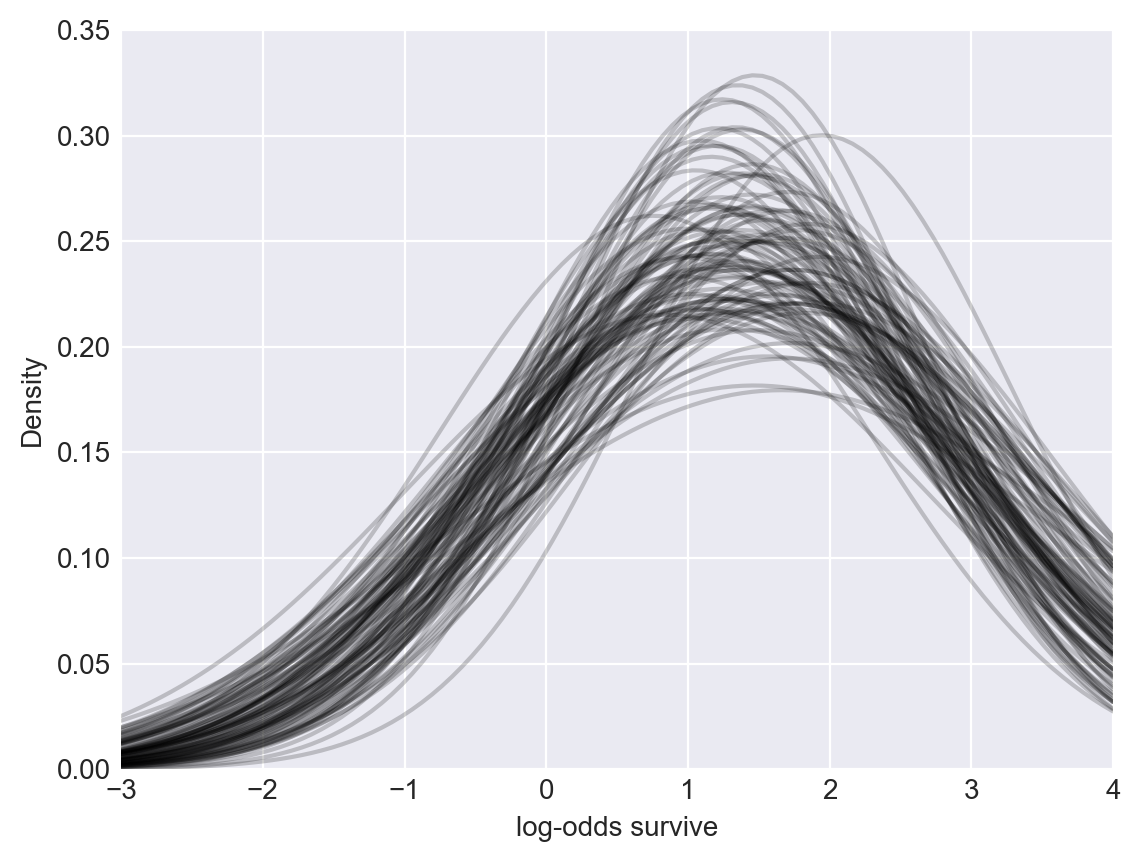

In [9]:
plt.plot()
plt.xlim(-3,4)
plt.ylim(0,.35)
plt.xlabel('log-odds survive')
plt.ylabel('Density')

post_samples = post.sample(1000)
a_bar = post_samples.a_bar.values.flatten()
sigma = post_samples.sigma.values.flatten()
x = np.linspace(-3,4,100)
for i in range(100):
    plt.plot(x, norm.pdf(x,a_bar[i], sigma[i]), color = 'black', alpha = 0.2)

samp_size = 8000
sim_tanks = np.random.normal(post.a_bar.sample(samp_size), post.sigma.sample(samp_size), size = samp_size)



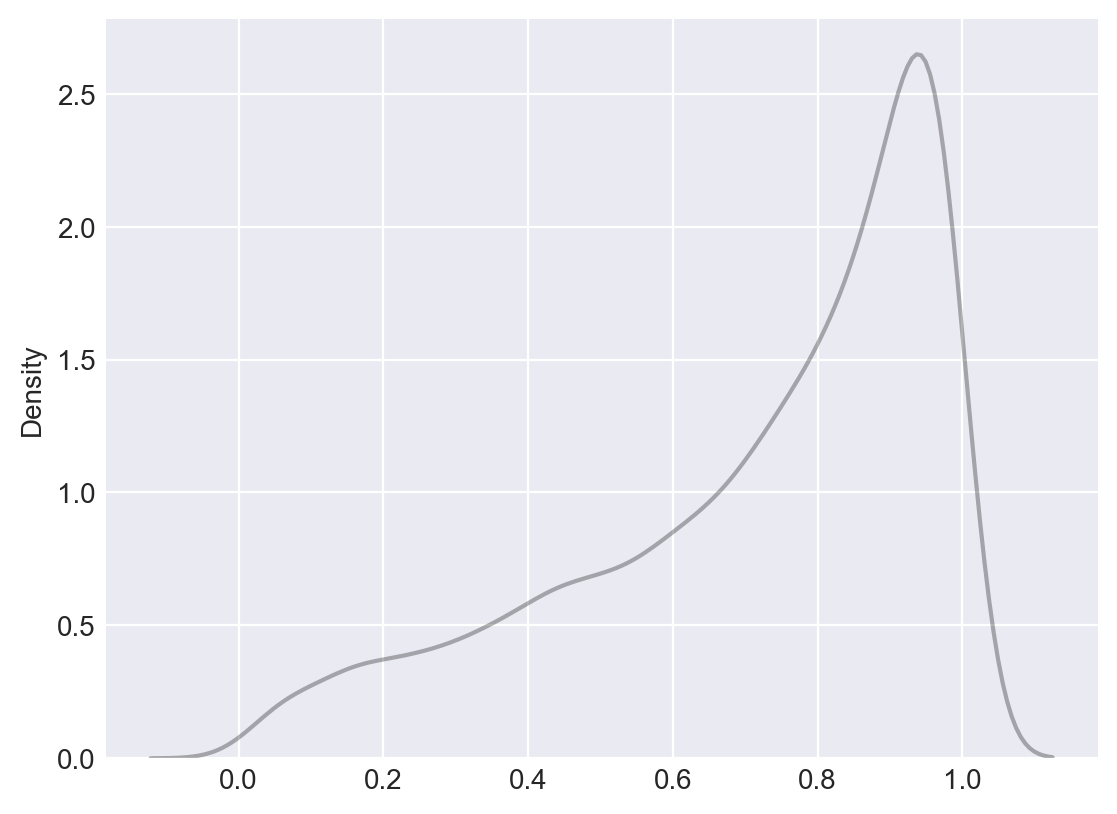

In [10]:
sns.kdeplot(inv_logit(sim_tanks), color = 'black', alpha = 0.3);

#### Code 13.7

In [11]:
a_bar = 1.5
sigma = 1.5
nponds = 60
Ni = np.repeat([5,15,25,35], 15)

#### Code 13.8

In [12]:
np.random.seed(5005)
a_pond = np.random.normal(loc = a_bar, scale = sigma, size = nponds)


#### Code 13.9

In [13]:
dsim = pd.DataFrame(
    {'pond': np.arange(0,nponds),
    'Ni': Ni,
    'true_a': a_pond}
)
dsim

,pond,Ni,true_a
0,0,5,-1.870347
1,1,5,3.750758
2,2,5,2.149985
3,3,5,2.158495
4,4,5,1.309652
5,5,5,2.371186
6,6,5,2.909742
7,7,5,-1.897807
8,8,5,3.854126
9,9,5,1.439286


#### Code 13.10

_This is just data type stuff in Stan.  Not very relevant to python_

#### Code 13.10

In [14]:
dsim['Si'] = np.random.binomial(n = dsim.Ni, p = inv_logit(dsim.true_a), size = nponds)

#### Code 13.12

In [15]:
dsim['p_nopool'] = dsim.Si / dsim.Ni

#### Cod 13.13

In [27]:
dat = pd.DataFrame({
    'Si': dsim.Si,
    'Ni': dsim.Ni,
    'pond': dsim.pond
})

with pm.Model() as m13_3:
    a_bar= pm.Normal('a_bar', 0, 1.5)
    sigma = pm.Exponential('sigma', 1)
    a_pond = pm.Normal('a_pond', mu = a_bar, sigma = sigma, shape = len(dat.pond.unique()))
    p = pm.Deterministic('p', pm.math.sigmoid(a_pond[dat.pond]))
    Si = pm.Binomial('Si', n = dsim.Ni, p = p, observed = dat.Si)
    trace_m13_3 = pm.sample(500, tune = 500, cores = 1, idata_kwargs={'log_likelihood': True})
pm.summary(trace_m13_3)

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [a_bar, sigma, a_pond]


Output()

Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 2 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a_bar,1.480,0.267,0.980,1.969,0.011,0.008,605.0,564.0,1.01
a_pond[0],-1.745,1.160,-3.918,0.481,0.037,0.032,1074.0,567.0,1.00
a_pond[1],2.911,1.317,0.700,5.600,0.041,0.032,1077.0,816.0,1.00
a_pond[2],2.895,1.286,0.626,5.317,0.039,0.032,1239.0,604.0,1.00
a_pond[3],2.897,1.384,0.693,5.616,0.047,0.040,1066.0,604.0,1.01
...,...,...,...,...,...,...,...,...,...
p[55],0.801,0.065,0.684,0.918,0.002,0.001,1321.0,849.0,1.00
p[56],0.361,0.077,0.204,0.492,0.002,0.001,1703.0,855.0,1.00
p[57],0.253,0.071,0.119,0.382,0.002,0.001,1115.0,677.0,1.00
p[58],0.932,0.038,0.864,0.992,0.001,0.001,1499.0,674.0,1.00


#### Code 13.14

In [28]:
pm.summary(trace_m13_3)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a_bar,1.480,0.267,0.980,1.969,0.011,0.008,605.0,564.0,1.01
a_pond[0],-1.745,1.160,-3.918,0.481,0.037,0.032,1074.0,567.0,1.00
a_pond[1],2.911,1.317,0.700,5.600,0.041,0.032,1077.0,816.0,1.00
a_pond[2],2.895,1.286,0.626,5.317,0.039,0.032,1239.0,604.0,1.00
a_pond[3],2.897,1.384,0.693,5.616,0.047,0.040,1066.0,604.0,1.01
...,...,...,...,...,...,...,...,...,...
p[55],0.801,0.065,0.684,0.918,0.002,0.001,1321.0,849.0,1.00
p[56],0.361,0.077,0.204,0.492,0.002,0.001,1703.0,855.0,1.00
p[57],0.253,0.071,0.119,0.382,0.002,0.001,1115.0,677.0,1.00
p[58],0.932,0.038,0.864,0.992,0.001,0.001,1499.0,674.0,1.00


#### Code 13.15

In [29]:
dsim['p_partpool'] = inv_logit(trace_m13_3.posterior.to_dataframe(
                                            ).reset_index(
                                            ).groupby('a_pond_dim_0'
                                            ).mean(
                                            )['a_pond'])


#### Code 13.16

In [30]:
dsim['p_true'] = inv_logit(dsim.true_a)

#### Code 13.17

In [31]:
nopool_error = abs(dsim.p_nopool - dsim.p_true)
partpool_error = abs(dsim.p_partpool - dsim.p_true)

#### Code 13.18

(-0.1, 0.42)

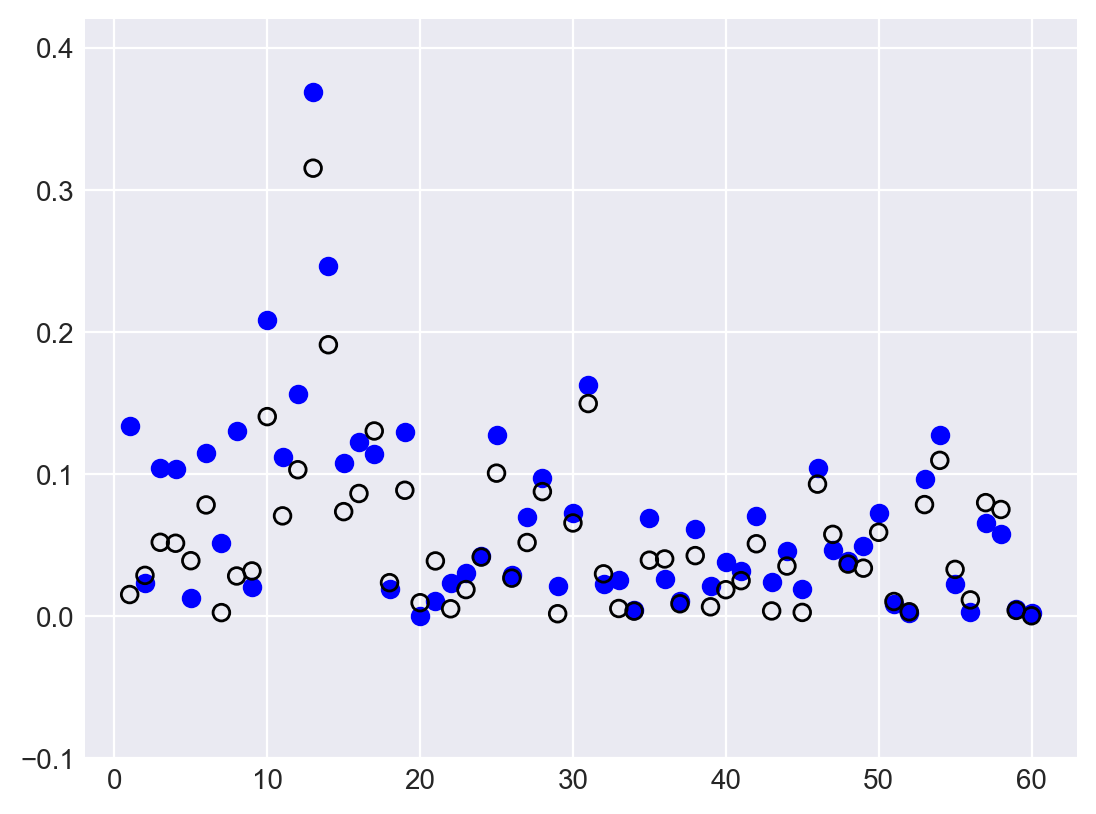

In [32]:
plt.scatter(np.linspace(1,60,60), nopool_error, color = 'blue')
plt.scatter(np.linspace(1,60,60), partpool_error, edgecolor = 'black', facecolor = 'none')
plt.ylim(-.1, .42)


#### Code 13.19

In [33]:
nopool_avg = dsim[['Ni','p_nopool']].groupby('Ni').mean()
partpool_avg = dsim[['Ni','p_partpool']].groupby('Ni').mean()

#### Code 13.20

_This overthinking box is also Stan-specific so we'll be skipping for now._


#### Code 13.21

In [4]:
d=  pd.read_csv('data/chimpanzees.csv', sep=';')
d['treatment'] = d.prosoc_left + 2 * d.condition 
dat_list = pd.DataFrame({
    'pulled_left': d.pulled_left,
    'actor': d.actor,
    'block_id': d.block,
    'treatment': d.treatment
})


np.random.seed(13)

with pm.Model() as m13_4:
    #Hyper-priors
    a_bar = pm.Normal('a_bar', 0, 1.5)
    sigma_a = pm.Exponential('sigma_a', 1)
    sigma_g = pm.Exponential('sigma_g', 1)

    #Adaptive Priors
    a = pm.Normal('a', a_bar, sigma_a, shape = len(dat_list.actor.unique()))
    g = pm.Normal('g', 0, sigma_g, shape = len(dat_list.block_id.unique()))

    #Linear model
    b = pm.Normal('b', 0, .5, shape = len(dat_list.treatment.unique()))
    p = pm.Deterministic('logit_p', pm.math.sigmoid(a[dat_list.actor] + g[dat_list.block_id] + b[dat_list.treatment]))
    pulled_left = pm.Binomial('pulled_left',  n = 1, p =p, observed = dat_list.pulled_left.values)
    trace_m13_4 = pm.sample(500, tune = 500, cores = 1, idata_kwargs= {'log_likelihood': True})

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [a_bar, sigma_a, sigma_g, a, g, b]


Output()

Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 196 seconds.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 1 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


#### Code 13.22

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a_bar,0.676,0.742,-0.762,1.941,0.076,0.054,93.0,191.0,1.02
a[0],2.215,0.404,1.527,2.985,0.083,0.059,24.0,198.0,1.07
a[1],-0.206,0.360,-0.793,0.510,0.076,0.055,23.0,93.0,1.08
a[2],4.897,1.389,2.651,7.632,0.236,0.168,38.0,74.0,1.07
a[3],-0.561,0.343,-1.133,0.091,0.051,0.037,45.0,77.0,1.01
...,...,...,...,...,...,...,...,...,...
logit_p[499],0.918,0.033,0.857,0.975,0.004,0.003,77.0,180.0,1.04
logit_p[500],0.918,0.033,0.857,0.975,0.004,0.003,77.0,180.0,1.04
logit_p[501],0.843,0.053,0.744,0.944,0.005,0.003,126.0,153.0,1.02
logit_p[502],0.843,0.053,0.744,0.944,0.005,0.003,126.0,153.0,1.02


array([<Axes: title={'center': '94.0% HDI'}>], dtype=object)

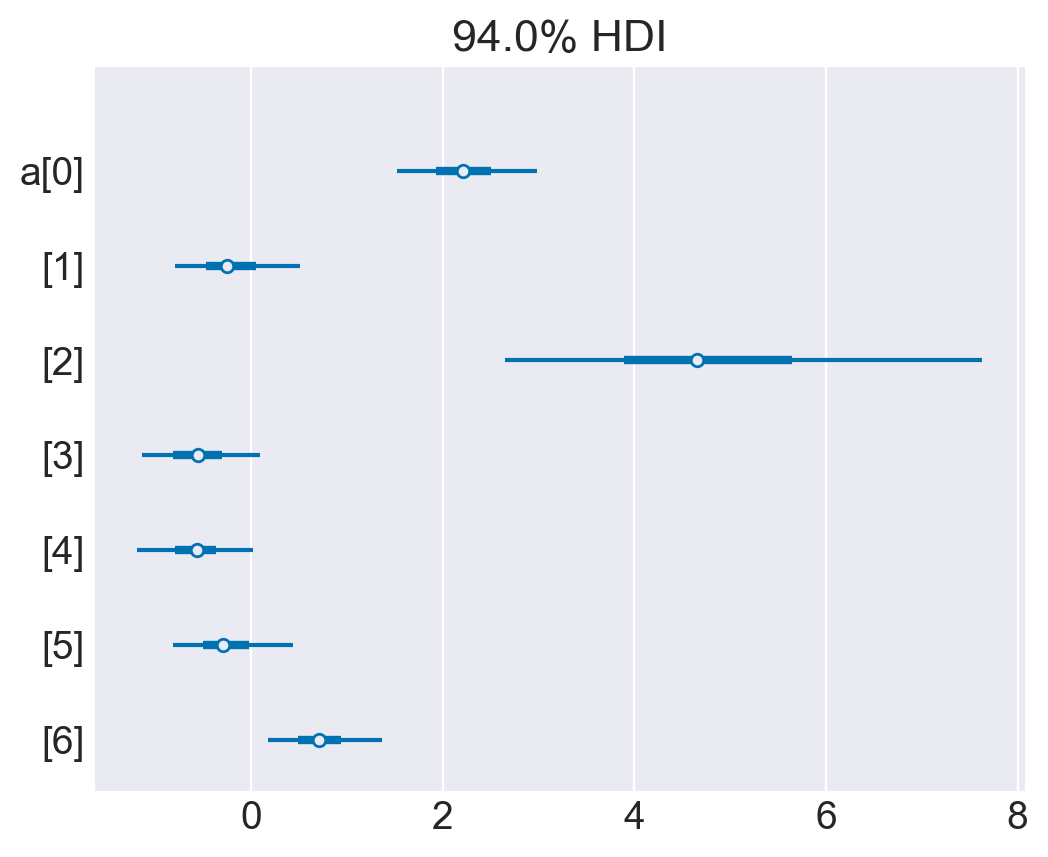

In [5]:
display(pm.summary(trace_m13_4))
az.plot_forest(trace_m13_4, combined = True, var_names = ['a'])

#### Code 13.23

In [6]:
with pm.Model() as m13_5:
    #Hyper-priors
    a_bar = pm.Normal('a_bar', 0, 1.5)
    sigma_a = pm.Exponential('sigma_a', 1)
    sigma_g = pm.Exponential('sigma_g', 1)

    #Adaptive Priors
    a = pm.Normal('a', a_bar, sigma_a, shape = len(dat_list.actor.unique()))
    b = pm.Normal('b', 0, .5, shape = len(dat_list.treatment.unique()))


    #Linear model
    logit_p = pm.Deterministic('logit_p', pm.math.sigmoid(a[dat_list.actor] + b[dat_list.treatment]))
    pulled_left = pm.Binomial('pulled_left',  n = 1, p =logit_p, observed = dat_list.pulled_left.values)
    trace_m13_5 = pm.sample(500, tune = 500, cores = 1, idata_kwargs= {'log_likelihood': True})

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [a_bar, sigma_a, sigma_g, a, b]


Output()

Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 172 seconds.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 1 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


#### Code 13.24

In [7]:
pm.compare({'m13_4':trace_m13_4, 'm13_5': trace_m13_5})

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
m13_5,0,-265.427828,8.449300,0.00000,1.0,9.600924,0.00000,False,log
m13_4,1,-265.925718,10.301443,0.49789,0.0,9.708735,0.83916,False,log


#### Code 13.25

In [ ]:
with pm.Model() as m13_6:
    #Hyper-priors
    a_bar = pm.Normal('a_bar', 0, 1.5)
    sigma_a = pm.Exponential('sigma_a', 1)
    sigma_g = pm.Exponential('sigma_g', 1)
    sigma_b = pm.Exponential('sigma_b', 1)

    #Adaptive Priors
    a = pm.Normal('a', a_bar, sigma_a, shape = len(dat_list.actor.unique()))
    g = pm.Normal('g', 0, sigma_g, shape = len(dat_list.block_id.unique()))
    b = pm.Normal('b', 0, sigma_b, shape = len(dat_list.treatment.unique()))


    #Linear model
    logit_p = pm.Deterministic('logit_p', pm.math.sigmoid(a[dat_list.actor] + g[dat_list.block_id] + b[dat_list.treatment]))
    pulled_left = pm.Binomial('pulled_left',  n = 1, p =logit_p, observed = dat_list.pulled_left.values)
    trace_m13_6 = pm.sample(500, tune = 500, cores = 1, idata_kwargs= {'log_likelihood': True})

df = pd.concat([pm.summary(trace_m13_4, var_names = ['b']),
                pm.summary(trace_m13_6, var_names = ['b'])])

Initializing NUTS using jitter+adapt_diag...


#### Code 13.26

In [ ]:
with pm.Model() as m13_7:
    v = pm.Normal('v',0,3)
    x = pm.Normal('x', 0, pm.math.exp(v))
    trace_m13_7 = pm.sample(500, tune= 500, idata_kwargs={'log_likelihood': True}, cores = 1)
pm.summary(trace_m13_7)

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [v, x]


Output()

Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 1 seconds.
There were 128 divergences after tuning. Increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
v,1.489,1.853,-0.969,5.045,0.401,0.287,21.0,58.0,1.10
x,0.193,40.188,-46.499,78.553,6.851,5.004,50.0,22.0,1.02


#### Code 13.27

In [ ]:
with pm.Model() as m13_8:
    v = pm.Normal('v',0,3)
    z = pm.Normal('z', 0,1)
    x = pm.Deterministic('x',z*pm.math.exp(v))
    trace_m13_8 = pm.sample(500, tune= 500, idata_kwargs={'log_likelihood': True}, cores = 1)
pm.summary(trace_m13_8)

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [v, z]


Output()

Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 1 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
v,0.039,2.903,-5.477,5.214,0.083,0.092,1235.0,748.0,1.0
z,-0.014,1.006,-1.936,1.724,0.031,0.031,1021.0,568.0,1.0
x,9.456,310.249,-74.044,49.363,10.937,7.736,732.0,723.0,1.0


#### Code 13.28

In [ ]:
with m13_4:
    trace_m13_4b = pm.sample(500, tune=500, cores = 1, target_accept = .99)

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [a_bar, sigma_a, sigma_g, a, g, b]


Output()

Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 197 seconds.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 1 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


#### Code 13.29

In [ ]:
with pm.Model() as m13_4nc:
    #Hyper-priors
    a_bar = pm.Normal('a_bar', 0, 1.5)
    sigma_a = pm.Exponential('sigma_a', 1)
    sigma_g = pm.Exponential('sigma_g', 1)
    b = pm.Normal('b', 0, .5, shape = len(dat_list.treatment.unique()))

    #Non-center transforms
    z = pm.Normal('z', 0, 1, shape = len(dat_list.actor.unique()))
    x = pm.Normal('x', 0, 1, shape = len(dat_list.block_id.unique()))

    #New priors
    a = pm.Deterministic('a', a_bar  + z * sigma_a)
    g = pm.Deterministic('g', x * sigma_g)

    #Linear model
    logit_p = pm.Deterministic('logit_p', pm.math.sigmoid(a[dat_list.actor] 
                                                        + g[dat_list.block_id] 
                                                        + b[dat_list.treatment]))
    pulled_left = pm.Binomial('pulled_left',  n = 1, p =logit_p, observed = dat_list.pulled_left.values)
    trace_m13_4nc = pm.sample(500, tune = 500, cores = 1, idata_kwargs= {'log_likelihood': True})
    

Initializing NUTS using jitter+adapt_diag...


#### Code 13.30

In [ ]:


precis_c = pm.summary(trace_m13_4)
precis_nc = pm.summary(trace_m13_4nc)


prefixes = ['a_bar', 'sigma_a', 'sigma_g', 'a[', 'b[', 'g[']
params = [idx for idx in precis_c.index 
          if any(idx == p or idx.startswith(p) for p in prefixes)]

neff_table = pd.DataFrame({
    'pc': precis_c.loc[params, 'ess_bulk'].values,
    'pnc': precis_nc.loc[params, 'ess_bulk'].values
}, index=params)

plt.scatter(neff_table.pc, neff_table.pnc, edgecolor = 'black', facecolor = 'none')
plt.xlabel('n_eff (centered)')
plt.ylabel('n_eff (non-centered)')
plt.plot([0, 1], [0, 1], 'k--', transform=plt.gca().transAxes);

#### Code 13.31

In [ ]:
chimp = 2
d_pred = pd.DataFrame({
    'actor': np.repeat('chimp',4),
    'treatment': [1,2,3,4],
    'block_id': np.repeat(1,4)
})

post = trace_m13_4.posterior.to_dataframe().reset_index()

a = post['a'].values.reshape(-1, post['a'].shape[-1])
g = post['g'].values.reshape(-1, post['g'].shape[-1])
b = post['b'].values.reshape(-1, post['b'].shape[-1])

p = inv_logit(a[:, chimp, None] + g[:, d_pred['block'], None] + b[:, d_pred['treatments']])

p_mu = p.mean(axis=0)
p_ci = np.percentile(p, [5.5, 94.5], axis=0)

#### Code 13.32

In [ ]:
print(trace_m13_4)

#### Code 13.33

In [ ]:
sns.kdeplot(post.a.loc[post['a'] == 5])

#### Code 13.34

In [ ]:
def p_link(treatment:list, actor:int = 1, block_id:int = 1):
    logodds = a[:, chimp, None] + g[:, d_pred['block'], None] + b[:, d_pred['treatments']]
    return inv_logit(logodds)


#### Code 13.35

In [ ]:
p_raw = p_link([1,2,3,4], actor = 2, block_id = 1)
p_mu = p_raw.mean(1)
p_ci = np.percentile(p_raw, [5.5,94.5], axis = 0)

#### Code 13.36

In [ ]:
def p_link_abar (treatment):
    logodds = post.a_bar + post.b.loc[post['b'] == treatment]
    return inv_logit(logodds)

#### Code 13.37

In [ ]:
post = trace_m13_4.posterior.to_dataframe().reset_index()

p_raw = [p_link_abar(i) for i in [1,2,3,4]]
p_mu = p_raw.mean(1)
p_ci = np.percentile(p_raw, [5.5,94.5], axis = 0)

#### Code 13.38

In [ ]:
a_sim = np.random.normal(post.a_bar, post.sigma_a, post.a_bar.shape[0])

def p_link_asim(treatment):
    log_odds = post.a_bar + post.b.loc[post['b'] == treatment]
    return inv_logit(log_odds)

p_raw_asim = [p_link_asim(i) for i in [1,2,3,4]]


#### Code 13.39

In [ ]:
plt.figure(figsize = (12.12))
plt.xlabel('treatment')
plt.ylabel('proportion pulled left')
plt.ylim(0,1)
plt.xlim(1,4)

for i in range(100):
    plt.plot([1,2,3,4], p_raw_asim(i,))